Name = Arav Mahind

Roll = 24102A2008

Branch-Div = CMPN-A

Subject = R Programming

Assingment 02

# Lab 3: Control Flow for Data Cleaning

## Topic: Loops, Functions, and Error Handling in R

### Dataset: UCI Heart Disease Dataset

Install and Load Required Packages

In [2]:
# Install require package
install.packages("tidyverse")

# Load the package
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Load the UCI Heart Disease Dataset

In [21]:
# Download the dataset
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Read the dataset
heart_data <- read.csv(url, header=FALSE, na.strings="?")

colnames(heart_data) <- c(
  "age", "sex", "cp", "trestbps", "chol",
  "fbs", "restecg", "thalach", "exang",
  "oldpeak", "slope", "ca", "thal", "target"
)

Understand the Dataset

In [22]:
# Check the number of rows and columns
dim(heart_data)

[1] 303  14

In [23]:
# Display the first 6 rows
head(heart_data)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
6,56,1,2,120,236,0,0,178,0,0.8,1,0,3,0


In [24]:
# Get a statistical summary
summary(heart_data)

      age             sex               cp           trestbps    
 Min.   :29.00   Min.   :0.0000   Min.   :1.000   Min.   : 94.0  
 1st Qu.:48.00   1st Qu.:0.0000   1st Qu.:3.000   1st Qu.:120.0  
 Median :56.00   Median :1.0000   Median :3.000   Median :130.0  
 Mean   :54.44   Mean   :0.6799   Mean   :3.158   Mean   :131.7  
 3rd Qu.:61.00   3rd Qu.:1.0000   3rd Qu.:4.000   3rd Qu.:140.0  
 Max.   :77.00   Max.   :1.0000   Max.   :4.000   Max.   :200.0  
                                                                 
      chol            fbs            restecg          thalach     
 Min.   :126.0   Min.   :0.0000   Min.   :0.0000   Min.   : 71.0  
 1st Qu.:211.0   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:133.5  
 Median :241.0   Median :0.0000   Median :1.0000   Median :153.0  
 Mean   :246.7   Mean   :0.1485   Mean   :0.9901   Mean   :149.6  
 3rd Qu.:275.0   3rd Qu.:0.0000   3rd Qu.:2.0000   3rd Qu.:166.0  
 Max.   :564.0   Max.   :1.0000   Max.   :2.0000   Max.   :202.0  
   

Introduce Problematic BP Values

In [25]:
# Introduce some invalid and missing BP values

heart_data$trestbps[1] <- -120
heart_data$trestbps[2] <- 320
heart_data$trestbps[3] <- NA
heart_data$trestbps[4] <- -80
heart_data$trestbps[5] <- 350

# Check the modified BP values
heart_data$trestbps[1:10]

[1] -120  320   NA  -80  350  120  140  120  130  140

In [26]:
tail(heart_data)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
298,57,0,4,140,241,0,0,123,1,0.2,2,0,7,1
299,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
300,68,1,4,144,193,1,0,141,0,3.4,2,2,7,2
301,57,1,4,130,131,0,0,115,1,1.2,2,1,7,3
302,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1
303,38,1,3,138,175,0,0,173,0,0.0,1,NA,3,0


In [27]:
heart_data$trestbps[1:10]

[1] -120  320   NA  -80  350  120  140  120  130  140

Create the BP Cleaning Function

In [28]:
# Function to clean blood pressure values
clean_bp <- function(bp) {

  if(is.na(bp)) {
    return(NA)
  }
  else if(bp < 0) {
    return(NA)
  }
  else if(bp > 250) {
    return(250)
  }
  else {
    return(bp)
  }
}

In [29]:
clean_bp(-120)
clean_bp(320)
clean_bp(140)
clean_bp(NA)

[1] NA

[1] 250

[1] 140

[1] NA

In [30]:
# Apply the cleaning function to every BP value
heart_data$trestbps <- sapply(heart_data$trestbps, clean_bp)

heart_data$trestbps[1:10]

[1]  NA 250  NA  NA 250 120 140 120 130 140

Error Handling with tryCatch()

In [32]:
# Calculate mean BP safely
safe_mean_bp <- function(bp) {
  tryCatch (
    {
      mean(bp, na.rm=TRUE)
    },
    error = function(e) {
      message("Error while calculating mean BP: ", e$message)
      return(NA)
    }
  )
}

mean_bp <- safe_mean_bp(heart_data$trestbps)

mean_bp

[1] 132.39

Calculate chol / trestbps Safely

In [33]:
# Function to safely calculate cholesterol-to-BP ratio
safe_ratio <- function(chol, bp) {

  tryCatch(
    {
      if (is.na(bp)) {
        stop("Blood pressure is missing")
      } else if (bp <= 0) {
        stop("Blood pressure must be greater than zero")
      } else {
        return(chol / bp)
      }
    },
    error = function(e) {
      message("Cannot calculate ratio: ", e$message)
      return(NA)
    }
  )
}

# Test the function
safe_ratio(233, 145)
safe_ratio(233, 0)
safe_ratio(233, NA)

[1] 1.606897

Cannot calculate ratio: Blood pressure must be greater than zero



[1] NA

Cannot calculate ratio: Blood pressure is missing



[1] NA

Loop-Based BP Cleaning

In [34]:
# Create a copy of the BP column
bp_loop <- heart_data$trestbps

# Clean BP values using a for loop
for (i in seq_along(bp_loop)) {

  if (is.na(bp_loop[i])) {
    next
  } else if (bp_loop[i] < 0) {
    bp_loop[i] <- NA
  } else if (bp_loop[i] > 250) {
    bp_loop[i] <- 250
  }
}

# Check the first 10 values
bp_loop[1:10]

[1]  NA 250  NA  NA 250 120 140 120 130 140

Create Data for Performance Comparison

In [35]:
# Reload the original dataset for a fair comparison
comparison_data <- read.csv(
  url,
  header = FALSE,
  na.strings = "?"
)

colnames(comparison_data) <- c(
  "age", "sex", "cp", "trestbps", "chol",
  "fbs", "restecg", "thalach", "exang",
  "oldpeak", "slope", "ca", "thal", "target"
)

# Introduce the same problematic values
comparison_data$trestbps[1] <- -120
comparison_data$trestbps[2] <- 320
comparison_data$trestbps[3] <- NA
comparison_data$trestbps[4] <- -80
comparison_data$trestbps[5] <- 350

Measure Loop Execution Time

In [36]:
# Copy BP values
bp_loop <- comparison_data$trestbps

# Measure loop execution time
loop_time <- system.time({

  for (i in seq_along(bp_loop)) {

    if (is.na(bp_loop[i])) {
      next
    } else if (bp_loop[i] < 0) {
      bp_loop[i] <- NA
    } else if (bp_loop[i] > 250) {
      bp_loop[i] <- 250
    }
  }
})

loop_time

   user  system elapsed 
  0.008   0.000   0.008 

Vectorized Cleaning

In [37]:
# Copy original BP values
bp_vectorized <- comparison_data$trestbps

# Measure vectorized execution time
vectorized_time <- system.time({

  bp_vectorized[bp_vectorized < 0] <- NA
  bp_vectorized[bp_vectorized > 250] <- 250
})

vectorized_time

   user  system elapsed 
  0.001   0.000   0.000 

Compare Execution Times

In [38]:
# Compare the elapsed times
comparison <- data.frame(
  Method = c("For Loop", "Vectorized"),
  Time = c(loop_time["elapsed"], vectorized_time["elapsed"])
)

comparison

Method,Time
<chr>,<dbl>
For Loop,0.008
Vectorized,0.000


Verify Both Methods Give the Same Result

In [39]:
# Check whether both methods produced identical results
all.equal(bp_loop, bp_vectorized)

[1] TRUE

Validate the Cleaned BP Data

In [40]:
# Use the vectorized cleaned data
cleaned_bp <- bp_vectorized

# Count missing values
missing_count <- sum(is.na(cleaned_bp))

# Calculate statistics
minimum_bp <- min(cleaned_bp, na.rm = TRUE)
maximum_bp <- max(cleaned_bp, na.rm = TRUE)
mean_bp <- mean(cleaned_bp, na.rm = TRUE)
median_bp <- median(cleaned_bp, na.rm = TRUE)

# Display results
missing_count
minimum_bp
maximum_bp
mean_bp
median_bp

[1] 3

[1] 94

[1] 250

[1] 132.39

[1] 130

Verify No Invalid BP Values Remain

In [41]:
# Check for negative values
negative_values <- sum(cleaned_bp < 0, na.rm = TRUE)

# Check for values greater than 250
above_250 <- sum(cleaned_bp > 250, na.rm = TRUE)

negative_values
above_250

[1] 0

[1] 0

Save the Cleaned Dataset

In [42]:
# Put cleaned BP back into the dataset
comparison_data$trestbps <- cleaned_bp

# Save cleaned dataset
write.csv(
  comparison_data,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

## Lab 3 Conclusion

The BP data was successfully cleaned using a custom if-else function, tryCatch() error handling, a for loop, and vectorized operations. Negative and missing BP values were handled appropriately, while values above 250 mmHg were capped at 250. The vectorized approach was generally more efficient than the loop-based approach. The cleaned dataset was validated and saved as a CSV file.

LAB 4 — Advanced Missing Data Handling

Install and Load Lab 4 Packages

In [44]:
# Install required packages
install.packages("naniar")
install.packages("skimr")

# Load packages
library(naniar)
library(skimr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




Load the Adult Dataset

In [45]:
# Download the Adult dataset
adult_url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Column names
adult_columns <- c(
  "age", "workclass", "fnlwgt", "education",
  "education_num", "marital_status", "occupation",
  "relationship", "race", "sex", "capital_gain",
  "capital_loss", "hours_per_week",
  "native_country", "income"
)

# Read the dataset
adult_data <- read.csv(
  adult_url,
  header = FALSE,
  col.names = adult_columns,
  na.strings = "?"
)

# View first 6 rows
head(adult_data)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Inspect the Adult Dataset

In [46]:
# Check dimensions
dim(adult_data)

# Check structure
str(adult_data)

# View the dataset
View(adult_data)

[1] 32561    15

'data.frame':	32561 obs. of  15 variables:
 $ age           : int  39 50 38 53 28 37 49 52 31 42 ...
 $ workclass     : chr  " State-gov" " Self-emp-not-inc" " Private" " Private" ...
 $ fnlwgt        : int  77516 83311 215646 234721 338409 284582 160187 209642 45781 159449 ...
 $ education     : chr  " Bachelors" " Bachelors" " HS-grad" " 11th" ...
 $ education_num : int  13 13 9 7 13 14 5 9 14 13 ...
 $ marital_status: chr  " Never-married" " Married-civ-spouse" " Divorced" " Married-civ-spouse" ...
 $ occupation    : chr  " Adm-clerical" " Exec-managerial" " Handlers-cleaners" " Handlers-cleaners" ...
 $ relationship  : chr  " Not-in-family" " Husband" " Not-in-family" " Husband" ...
 $ race          : chr  " White" " White" " White" " Black" ...
 $ sex           : chr  " Male" " Male" " Male" " Male" ...
 $ capital_gain  : int  2174 0 0 0 0 0 0 0 14084 5178 ...
 $ capital_loss  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ hours_per_week: int  40 13 40 40 40 40 16 45 50 40 ...
 $ native_countr

age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K


Introduce Different Missing Values

In [47]:
# Introduce different types of missing/invalid data

adult_data$age[1] <- 999
adult_data$age[2] <- NA
adult_data$age[3] <- NaN

adult_data$workclass[4] <- ""
adult_data$occupation[5] <- ""

# Check modified values
adult_data[1:5, c("age", "workclass", "occupation")]

,age,workclass,occupation
,<dbl>,<chr>,<chr>
1,999,State-gov,Adm-clerical
2,NA,Self-emp-not-inc,Exec-managerial
3,NaN,Private,Handlers-cleaners
4,53,,Handlers-cleaners
5,28,Private,


Demonstrate NA, NaN, NULL and Blank

In [48]:
# Check NA
is.na(adult_data$age[2])

# Check NaN
is.nan(adult_data$age[3])

# Demonstrate NULL
example_object <- NULL
is.null(example_object)

# Check blank string
adult_data$workclass[4] == ""

# Check impossible age
adult_data$age[1] == 999

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

[1] TRUE

Missing-Value Summary

In [49]:
# Variable-wise missing-value summary
miss_var_summary(adult_data)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,2,0.006[4m1[24m[4m4[24m
workclass,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,0,0
relationship,0,0
race,0,0


# Variable-wise missing-value summary
miss_var_summary(adult_data)

In [50]:
# Convert impossible ages to NA
adult_data$age[adult_data$age == 999] <- NA

# Replace blank categorical values with "Unknown"
adult_data$workclass[adult_data$workclass == ""] <- "Unknown"
adult_data$occupation[adult_data$occupation == ""] <- "Unknown"

# Check the cleaned values
adult_data[1:5, c("age", "workclass", "occupation")]

,age,workclass,occupation
,<dbl>,<chr>,<chr>
1,NA,State-gov,Adm-clerical
2,NA,Self-emp-not-inc,Exec-managerial
3,NaN,Private,Handlers-cleaners
4,53,Unknown,Handlers-cleaners
5,28,Private,Unknown


Custom Median Imputation Function

In [51]:
# Function to replace missing values with the median
median_impute <- function(x) {

  median_value <- median(x, na.rm = TRUE)

  x[is.na(x)] <- median_value

  return(x)
}

Apply Median Imputation

In [52]:
# Apply median imputation to age
adult_data$age <- median_impute(adult_data$age)

# Apply median imputation to selected numeric variables
adult_data$fnlwgt <- median_impute(adult_data$fnlwgt)
adult_data$education_num <- median_impute(adult_data$education_num)
adult_data$hours_per_week <- median_impute(adult_data$hours_per_week)

# Check for missing values
sum(is.na(adult_data$age))

[1] 0

Check Complete and Incomplete Rows

In [53]:
# Identify complete rows
complete_rows <- complete.cases(adult_data)

# Count complete rows
sum(complete_rows)

# Count incomplete rows
sum(!complete_rows)

[1] 32561

[1] 0

Missingness After Cleaning

In [54]:
# Missing-value summary after cleaning
miss_var_summary(adult_data)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,0,0
workclass,0,0
fnlwgt,0,0
education,0,0
education_num,0,0
marital_status,0,0
occupation,0,0
relationship,0,0
race,0,0


Visualize Missingness

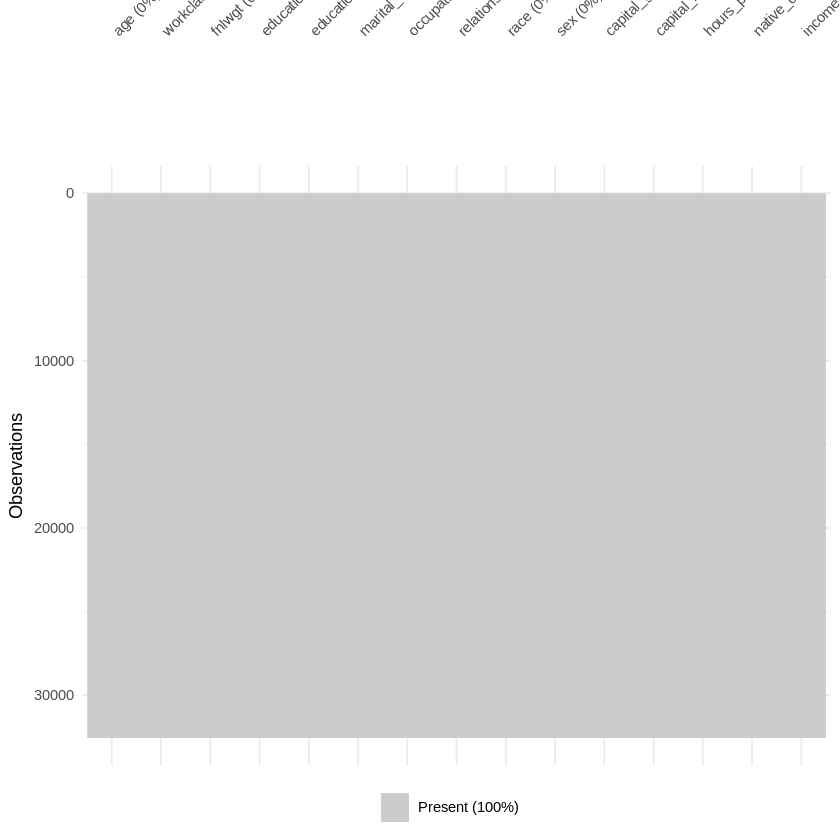

In [55]:
# Visualize missing data
vis_miss(adult_data)

Validate Using skim()

In [57]:
# Comprehensive dataset summary
skim(adult_data)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,2,17,0,10,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,4,13,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital_status,0,1,8,22,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,2,18,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,5,15,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,6,19,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,1,5,7,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native_country,0,1,2,27,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,5,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


Final Validation

In [58]:
# Check that impossible age value is gone
sum(adult_data$age == 999, na.rm = TRUE)

# Check blank workclass values
sum(adult_data$workclass == "", na.rm = TRUE)

# Check blank occupation values
sum(adult_data$occupation == "", na.rm = TRUE)

# Check missing values in selected numeric variables
sum(is.na(adult_data$age))
sum(is.na(adult_data$fnlwgt))
sum(is.na(adult_data$education_num))
sum(is.na(adult_data$hours_per_week))

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

Save Cleaned Adult Dataset

In [59]:
# Save the cleaned Adult dataset
write.csv(
  adult_data,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

## Lab 4 Conclusion

The Adult dataset was successfully analyzed for different types of missing and invalid data, including NA, NaN, blank values, and impossible age values. Appropriate cleaning strategies were applied, including replacing blank categorical values with "Unknown" and imputing missing numeric values using the median. Missingness was analyzed before and after cleaning, visualized using naniar, and the final dataset was validated using skimr.